In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib 
import os

C:\Users\Luis\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
os.chdir('C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #set directory for desktop
#os.chdir('/Users/sandoval/Library/CloudStorage/Box-Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #this is for when i use my mac instead of my desktop
raw = pd.read_csv('Full Summary Features 7-24-2025.csv') #filtered summary data from madison

In [3]:
#i want to see all the columns so i can specifically pick the features i actually want
    #we are going to make a dataset containing just restrict alongside predictors aka physio
    #then we are going to make another dataset containing just urge to restrict alongside physio
    #we don't want to include any other EMA in our train/test data for each analysis

for col in raw.columns: 
    print(col) 

Unnamed: 0
Time
HR_Mean
HR_Minimum
HR_Maximum
HR_Stdev
HR_RMS
HR_MAV
HR_Median
HR_P25
HR_P75
HR_Slope
EDA_Mean
EDA_Minimum
EDA_Maximum
EDA_Stdev
EDA_RMS
EDA_MAV
EDA_Median
EDA_P25
EDA_P75
EDA_Slope
TEMP_Mean
TEMP_Minimum
TEMP_Maximum
TEMP_Stdev
TEMP_RMS
TEMP_MAV
TEMP_Median
TEMP_P25
TEMP_P75
TEMP_Slope
meanCenteredEDA_Mean
meanCenteredEDA_Minimum
meanCenteredEDA_Maximum
meanCenteredEDA_Stdev
meanCenteredEDA_RMS
meanCenteredEDA_MAV
meanCenteredEDA_Median
meanCenteredEDA_P25
meanCenteredEDA_P75
meanCenteredEDA_Slope
meanCenteredHR_Mean
meanCenteredHR_Minimum
meanCenteredHR_Maximum
meanCenteredHR_Stdev
meanCenteredHR_RMS
meanCenteredHR_MAV
meanCenteredHR_Median
meanCenteredHR_P25
meanCenteredHR_P75
meanCenteredHR_Slope
meanCenteredTEMP_Mean
meanCenteredTEMP_Minimum
meanCenteredTEMP_Maximum
meanCenteredTEMP_Stdev
meanCenteredTEMP_RMS
meanCenteredTEMP_MAV
meanCenteredTEMP_Median
meanCenteredTEMP_P25
meanCenteredTEMP_P75
meanCenteredTEMP_Slope
ethica_time
lag
tdif
cumsumT
ethica_time_utc
day

In [4]:
#descriptives for paper

raw['restrict'].mean()
raw['restrict'].min()
raw['restrict'].max()
raw['restrict'].std()

33.56789632239403

In [5]:
raw['urge_restrict'].mean()
raw['urge_restrict'].min()
raw['urge_restrict'].max()
raw['urge_restrict'].std()

30.810261362815815

In [6]:
#row_nan_count = .isna().sum(axis=1)

raw["urge_restrict"].isna().sum() #71 urge_restrict points missing 
raw["restrict"].isna().sum() #54 restrict items missing
len(raw["urge_restrict"])
raw

,Unnamed: 0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAV,HR_Median,HR_P25,...,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered,PR,unique
0,0,2020-12-09 14:54:00,88.744522,73.17,103.47,6.505839,88.982574,103.47,89.37,83.67,...,0.279661,-1.0,-2.788136,-13.0,26.110169,15.5,0.0,0.0,PR003,1
1,1,2020-12-09 00:24:00,79.124461,51.55,107.33,14.197488,80.387592,107.33,78.45,70.92,...,0.279661,-1.0,18.211864,8.0,7.110169,-3.5,0.0,0.0,PR003,2
2,2,2020-12-08 19:30:00,66.492599,54.12,88.70,8.862043,67.080316,88.70,64.57,60.28,...,0.279661,-1.0,8.211864,-2.0,18.110169,7.5,0.0,0.0,PR003,3
3,3,2020-12-08 17:59:00,60.827888,47.20,73.68,5.746152,61.098580,73.68,61.47,56.02,...,2.279661,1.0,17.211864,7.0,18.110169,7.5,0.0,0.0,PR003,4
4,4,2020-12-07 22:58:00,52.120404,40.58,66.08,5.952649,52.459087,66.08,51.93,48.53,...,-0.720339,-2.0,16.211864,6.0,17.110169,6.5,0.0,0.0,PR003,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1951,59,2022-02-28 14:18:00,101.851703,77.92,187.35,27.662888,105.539974,187.35,89.95,84.03,...,0.741573,0.0,-22.977528,-25.0,-0.314607,1.0,0.0,0.0,PR128,1952
1952,60,2022-02-25 22:40:00,95.832491,73.85,121.93,12.922097,96.699417,121.93,95.38,84.83,...,-7.258427,-8.0,26.022472,24.0,4.685393,6.0,0.0,0.0,PR128,1953
1953,61,2022-02-25 21:11:00,75.666356,63.68,82.35,4.902798,75.824962,82.35,76.73,73.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PR128,1954
1954,62,2022-02-25 18:23:00,83.565743,64.30,123.05,16.279685,85.136075,123.05,78.07,71.42,...,18.741573,18.0,27.022472,25.0,16.685393,18.0,0.0,0.0,PR128,1955


In [7]:
#adding diagnoses

diag = pd.read_csv('ScreeningsR15-EDDiagnosticsSummary_DATA_2024-02-25_1408.csv') #dataframe containing diagnoses by ID
diag["PR"] = diag['record_id_73f3b8'] #making a column to match IDs
diag = diag.filter(['PR', 'currentdx1_ade7bc']) #i want to only merge the current general diagnoses and keep the ID variable
raw = diag.merge(raw, how = 'inner', on = 'PR') #we made it 

raw.head()

,PR,currentdx1_ade7bc,Unnamed: 0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAV,...,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered,unique
0,PR003,1.0,0,2020-12-09 14:54:00,88.744522,73.17,103.47,6.505839,88.982574,103.47,...,0.0,0.279661,-1.0,-2.788136,-13.0,26.110169,15.5,0.0,0.0,1
1,PR003,1.0,1,2020-12-09 00:24:00,79.124461,51.55,107.33,14.197488,80.387592,107.33,...,0.0,0.279661,-1.0,18.211864,8.0,7.110169,-3.5,0.0,0.0,2
2,PR003,1.0,2,2020-12-08 19:30:00,66.492599,54.12,88.70,8.862043,67.080316,88.70,...,0.0,0.279661,-1.0,8.211864,-2.0,18.110169,7.5,0.0,0.0,3
3,PR003,1.0,3,2020-12-08 17:59:00,60.827888,47.20,73.68,5.746152,61.098580,73.68,...,0.0,2.279661,1.0,17.211864,7.0,18.110169,7.5,0.0,0.0,4
4,PR003,1.0,4,2020-12-07 22:58:00,52.120404,40.58,66.08,5.952649,52.459087,66.08,...,0.0,-0.720339,-2.0,16.211864,6.0,17.110169,6.5,0.0,0.0,5


In [8]:
#random seed. I picked 6 because I like 6 and i always pick 6. this is so we get the same results every time
np.random.seed(6)

In [9]:
corrs = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev',  
                    'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median',
                    'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredEDA_Slope', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                    'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD',
                    'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 'meanCenteredHR_Slope',
                    'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev',
                    'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median',
                    'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'meanCenteredTEMP_Slope', 'urge_restrict', 'restrict'])

In [10]:
corrs = corrs.rename(columns={"meanCenteredEDA_Mean" : "EDA_Mean",
                      "meanCenteredEDA_Minimum" : "EDA_Minimum",
                      "meanCenteredEDA_Maximum" : "EDA_Maximum",
                      "meanCenteredEDA_Stdev" : "EDA_Stdev",
                      "meanCenteredEDA_RMS" : "EDA_RMS",
                      "meanCenteredEDA_MAD" : "EDA_MAD",
                      "meanCenteredEDA_MAV" : "EDA_MAV",
                      "meanCenteredEDA_Median" : "EDA_Median",
                      "meanCenteredEDA_P25" : "EDA_P25",
                      "meanCenteredEDA_P75" : "EDA_P75",
                      "meanCenteredEDA_Slope" : "EDA_Slope",
                      "meanCenteredHR_Mean" : "HR_Mean",
                      "meanCenteredHR_Minimum" : "HR_Minimum",
                      "meanCenteredHR_Maximum" : "HR_Maximum",
                      "meanCenteredHR_Stdev" : "HR_Stdev",
                      "meanCenteredHR_RMS" : "HR_RMS",
                      "meanCenteredHR_MAD" : "HR_MAD",
                      "meanCenteredHR_MAV" : "HR_MAV",
                      "meanCenteredHR_Median" : "HR_Median",
                      "meanCenteredHR_P25" : "HR_P25",
                      "meanCenteredHR_P75" : "HR_P75",
                      "meanCenteredHR_Slope" : "HR_Slope",
                      "meanCenteredTEMP_Mean" : "TEMP_Mean",
                      "meanCenteredTEMP_Minimum" : "TEM_Minimum",
                      "meanCenteredTEMP_Maximum" : "TEMP_Maximum",
                      "meanCenteredTEMP_Stdev" : "TEMP_Stdev",
                      "meanCenteredTEMP_RMS" : "TEMP_RMS",
                      "meanCenteredTEMP_MAD" : "TEMP_MAD",
                      "meanCenteredTEMP_MAV" : "TEMP_MAV",
                      "meanCenteredTEMP_Median" : "TEMP_Median",
                      "meanCenteredTEMP_P25" : "TEMP_P25",
                      "meanCenteredTEMP_P75" : "TEMP_P75",
                      "meanCenteredTEMP_Slope" : "TEMP_Slope",
                      "urge_restrict" : "urge_restrict",
                      "restrict" : "restrict"})

In [11]:
Corr_Matrix = round(corrs.corr(),2)
print(Corr_Matrix)

               EDA_Mean  EDA_Minimum  EDA_Maximum  EDA_Stdev  EDA_RMS  \
EDA_Mean           1.00         0.86         0.93       0.69     0.92   
EDA_Minimum        0.86         1.00         0.65       0.28     0.70   
EDA_Maximum        0.93         0.65         1.00       0.89     0.92   
EDA_Stdev          0.69         0.28         0.89       1.00     0.77   
EDA_RMS            0.92         0.70         0.92       0.77     1.00   
EDA_MAV            0.88         0.58         0.97       0.90     0.96   
EDA_Median         1.00         0.87         0.90       0.65     0.91   
EDA_P25            0.98         0.93         0.85       0.54     0.87   
EDA_P75            0.99         0.80         0.95       0.76     0.93   
EDA_Slope         -0.03        -0.15         0.12       0.26     0.02   
HR_Mean            0.11         0.07         0.12       0.11     0.15   
HR_Minimum         0.10         0.07         0.12       0.10     0.13   
HR_Maximum         0.07         0.05         0.08  

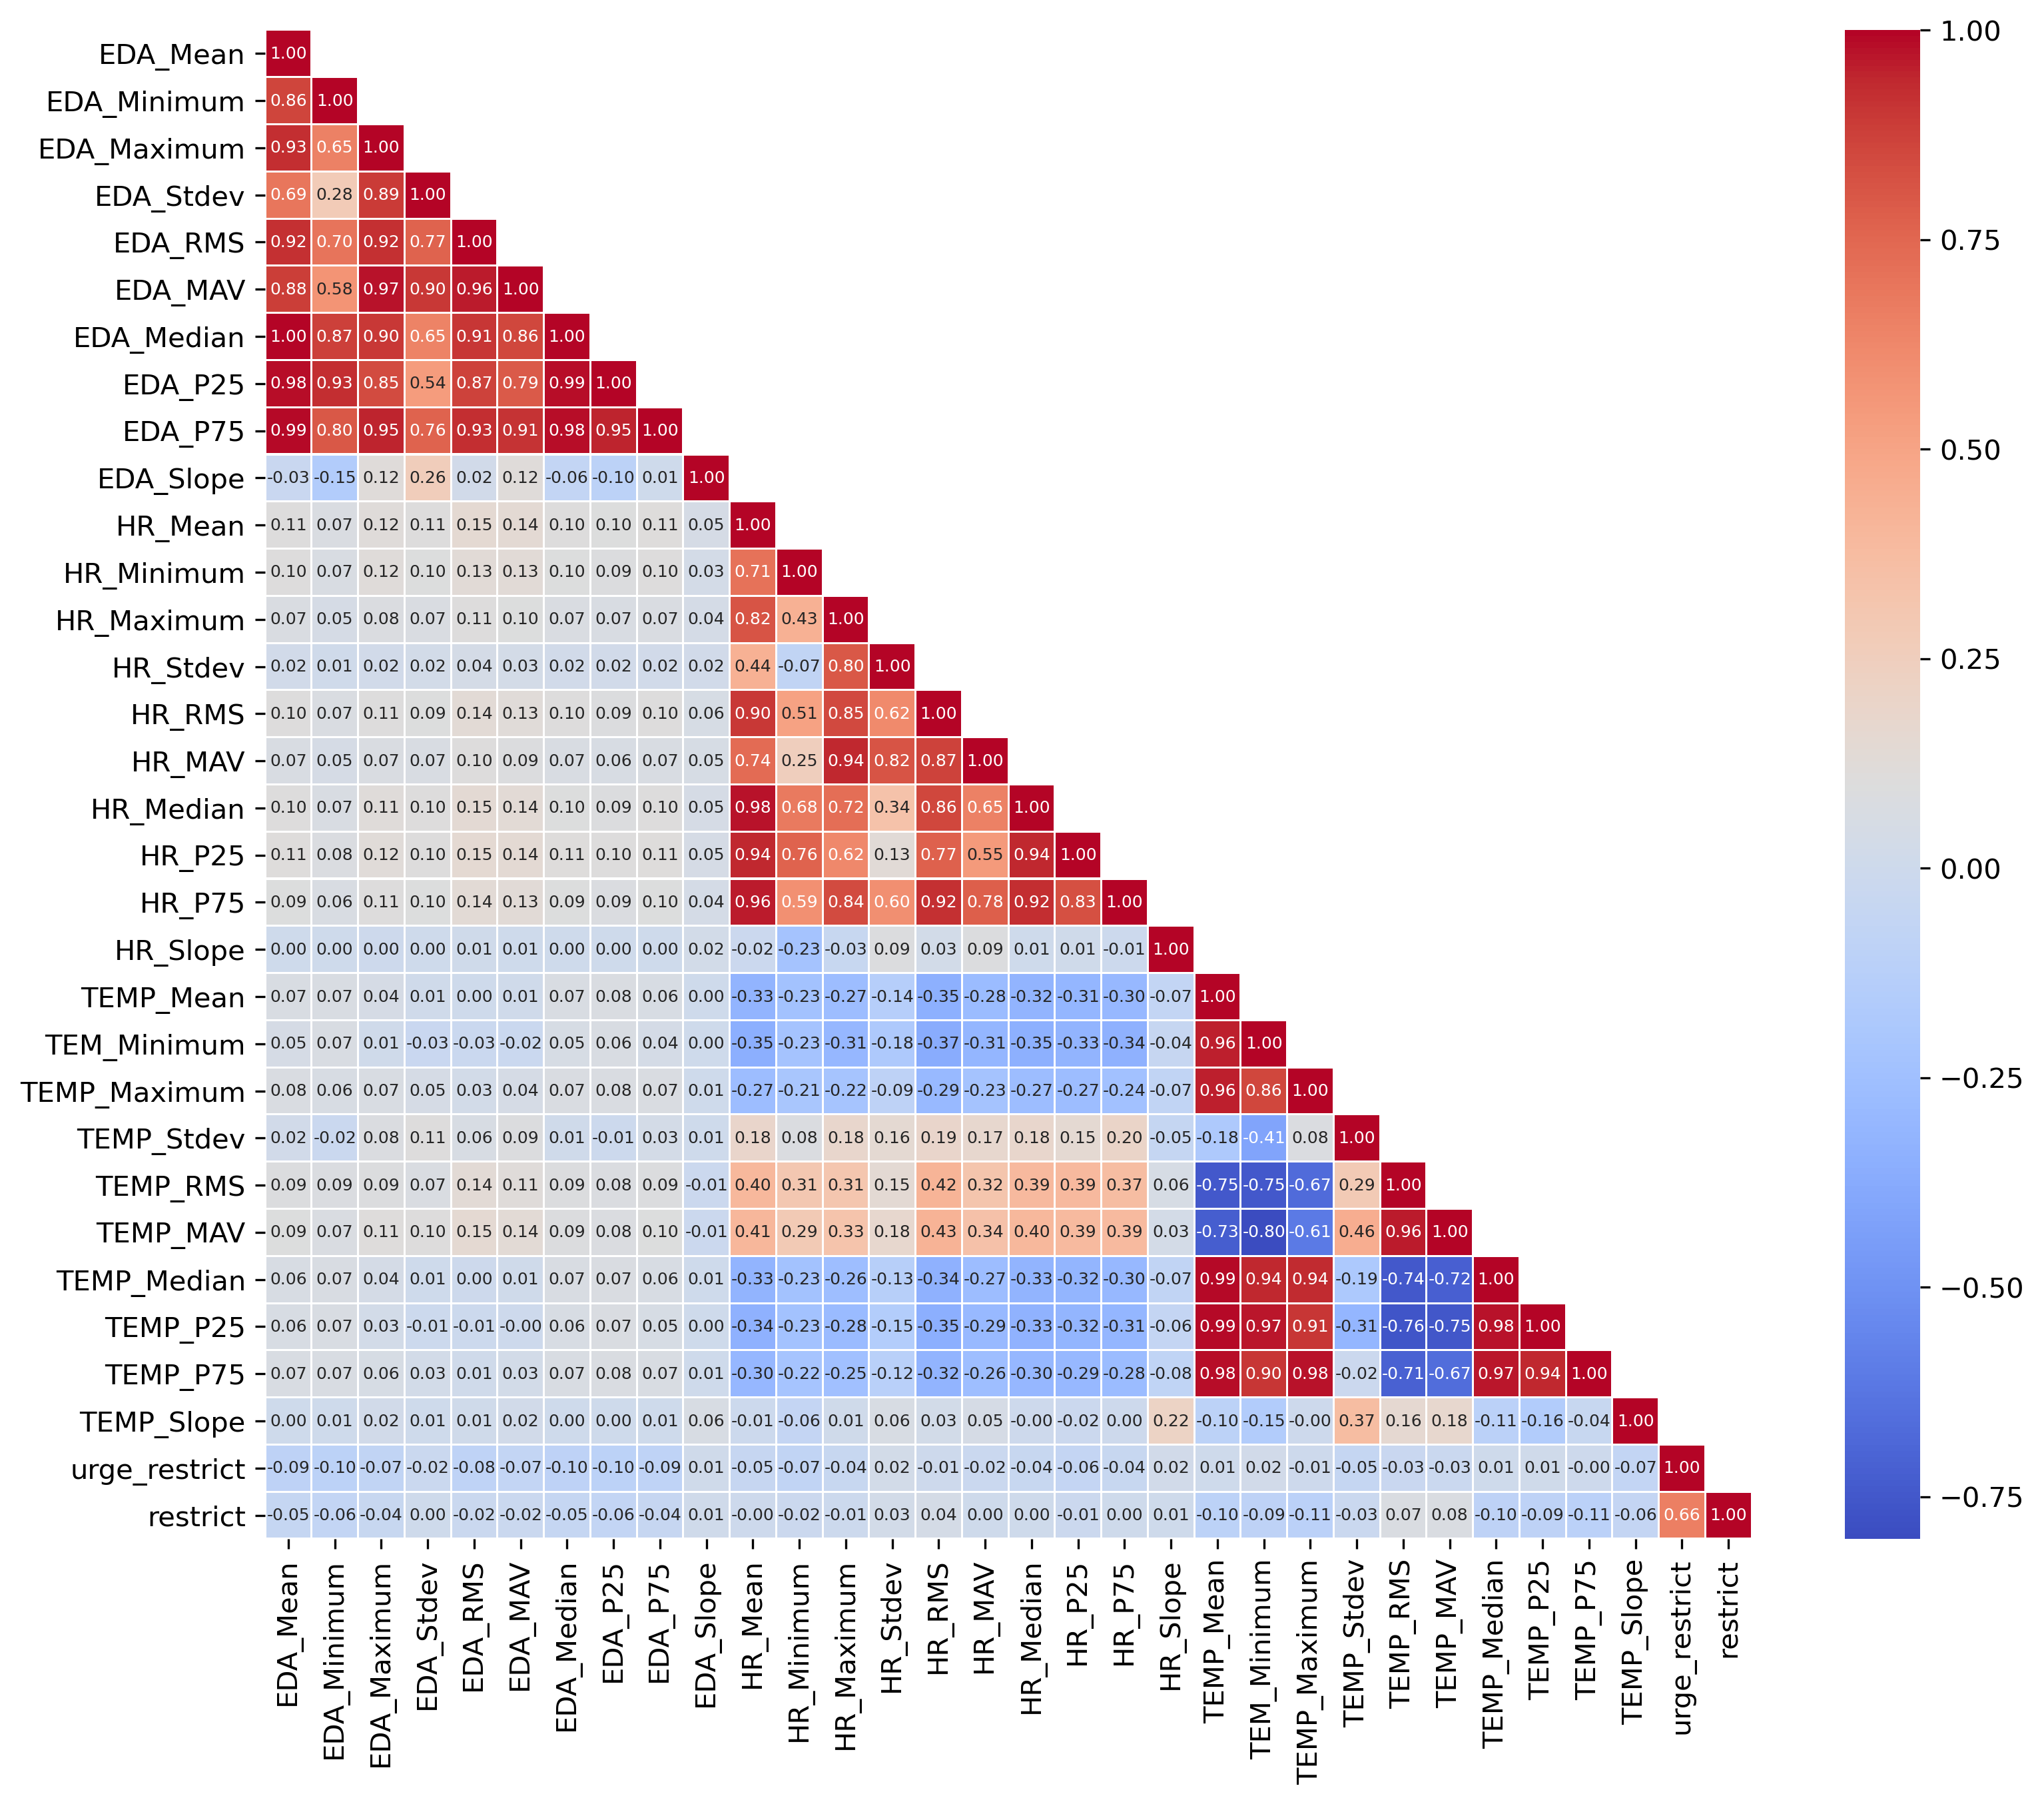

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_full = corrs.corr()

mask = np.zeros_like(correlation_full, dtype=bool)
mask[np.triu_indices_from(mask)] = True
np.fill_diagonal(mask, False)
 
plt.figure(figsize=(12,10), dpi =300)
sns.heatmap(correlation_full,fmt=".2f", linewidth=.5, cmap = 'coolwarm', mask = mask, annot=True,annot_kws={"fontsize": 6})
plt.show()

#the most correlated features EDA are Mean for central tendency and MAV for dispersion for restrict
#the most for HR are RMS for central tendency and Stdev for dispersion for restrict
#for temp, mean for central tendency and MAV for dispersion for restrict

#urge is most associated with EDA MAV for dispersion and Median for central tendency
#HR Mean and Stdev for urge
#TEMP Stdev and RMS for urge

In [13]:
raw['PR'] = raw['PR'].astype('category')
raw['PR']

0       PR003
1       PR003
2       PR003
3       PR003
4       PR003
        ...  
1951    PR128
1952    PR128
1953    PR128
1954    PR128
1955    PR128
Name: PR, Length: 1956, dtype: category
Categories (37, object): ['PR003', 'PR008', 'PR010', 'PR011', ..., 'PR116', 'PR117', 'PR126', 'PR128']

In [14]:
#creating the dataset for predicting urge_restrict from physio alone
urgeData = raw.filter(['PR', 'currentdx1_ade7bc', 'beepconsec','meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 
                       'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 
                       'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 
                       'meanCenteredEDA_Slope', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 'meanCenteredHR_Maximum', 
                       'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 'meanCenteredHR_MAV', 
                       'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 'meanCenteredHR_Slope',
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 
                       'meanCenteredTEMP_Stdev', 'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 
                       'meanCenteredTEMP_Median', 'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'meanCenteredTEMP_Slope',
                       'urge_restrict'])

urgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(urgeData['urge_restrict'])) #check that NAs exist - if false, we are good

False

In [15]:
restrictData = raw.filter(['PR', 'currentdx1_ade7bc','beepconsec','meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 
                           'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 
                           'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 
                           'meanCenteredEDA_Slope', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 'meanCenteredHR_Maximum', 
                           'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 'meanCenteredHR_MAV', 
                           'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 'meanCenteredHR_Slope', 
                           'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 
                           'meanCenteredTEMP_Stdev', 'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 
                           'meanCenteredTEMP_Median', 'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'meanCenteredTEMP_Slope', 
                           'restrict'])


restrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictData['restrict'])) #check that NAs exist - if false, we are good

False

In [16]:
import time
import datetime

urgeData = urgeData.sort_values(by='beepconsec', ascending = True)

restrictData = restrictData.sort_values(by='beepconsec', ascending = True)

In [17]:
#I want to keep urgeData and restrictData as is with the variables that allow me to unify the data later...
#in the meantime I need dataframes without the ID, diagnosis, and beep variables because the cross validation won't run
#this data will be used for cross-validation

urgeX_cross = urgeData.drop(['urge_restrict'], axis=1)
urgey_cross = urgeData.filter(['urge_restrict', 'PR', 'currentdx1_ade7bc','beepconsec']) #make a dataframe containing only urge_restrict variable

restX_cross = restrictData.drop(['restrict'], axis=1)
resty_cross = restrictData.filter(['restrict', 'PR', 'currentdx1_ade7bc','beepconsec'])

In [18]:
#data splitting for final model validation

from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5) 

for train_index, test_index in cv.split(urgeX_cross):
    urgeX_train, urgeX_test = urgeX_cross.iloc[train_index, :], urgeX_cross.iloc[test_index,:]
    urgey_train, urgey_test = urgey_cross.iloc[train_index], urgey_cross.iloc[test_index]
    
urgeX_train_clean = urgeX_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgeX_test_clean = urgeX_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgey_train_clean = urgey_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgey_test_clean = urgey_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

urgeX_cv_train = urgeX_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgey_cv_train = urgey_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from numpy import arange

#we're going to start exclusively with the urge data for now, we'll circle back to the restrict data later 

urgeMod = ElasticNet(max_iter = 5000) 

In [20]:
from numpy import mean
from numpy import std
from numpy import absolute

#developing a grid search cross-validation function that will provide us with a dictionary that contains the hyperparameters
#the dictionary with hyperparameters will allow us to automatically plug in our best hyperparameters 
def cross_validation(model, _X, _y, _cv):
    param_grid = {'alpha'     : [0.1,1,10,0.01],
                'l1_ratio'  :  np.arange(0.40,1.00,0.10),
                'tol'       : [0.0001,0.001] }
    _scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
    grid_search = GridSearchCV(estimator = model, param_grid = param_grid, cv = _cv, scoring = _scoring, return_train_score = True, refit= 'neg_root_mean_squared_error', n_jobs = -1)
    grid_search.fit(X = _X, y = _y,)
    d = dict()
    d['results'] = pd.DataFrame(grid_search.cv_results_)
    alpha = format(grid_search.best_params_).partition("{'alpha': ")[2] #alpha parameter
    d['alpha'] = alpha.partition(",")[0]
    l1 = format(grid_search.best_params_).partition("'l1_ratio': ")[2] #L1 ratio parameter
    d['l1'] = l1.partition(",")[0]
    tol = format(grid_search.best_params_).partition("'tol': ")[2] #tolerance parameter
    d['tol'] = tol.partition("}")[0]
    ind = format(grid_search.best_index_) #best index - this will be used to find our associated test R2
    d['ind'] = ind
    print("Best parameters : {}".format(grid_search.best_params_))
    return d
           

In [21]:
urgecv_result = cross_validation(urgeMod, urgeX_cv_train, urgey_cv_train, cv) #this does the cross validation

Best parameters : {'alpha': 1, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}


In [22]:
urgecv_result

{'results':     mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
 0        0.030458      0.008375         0.005614    8.063185e-04         0.1   
 1        0.029160      0.007591         0.006615    9.710758e-04         0.1   
 2        0.028654      0.007734         0.005903    6.601499e-04         0.1   
 3        0.030347      0.009229         0.005905    6.587082e-04         0.1   
 4        0.037033      0.014465         0.007605    2.415581e-03         0.1   
 5        0.037012      0.011399         0.008401    4.080157e-03         0.1   
 6        0.040809      0.007987         0.007001    1.673541e-03         0.1   
 7        0.039209      0.010050         0.005801    7.485576e-04         0.1   
 8        0.043010      0.014230         0.006201    1.939576e-03         0.1   
 9        0.033807      0.006114         0.005602    4.901350e-04         0.1   
 10       0.050212      0.005707         0.006602    1.019636e-03         0.1   
 11       0.03760

In [23]:
### now we build the final model for urge - we are using the optimal hyperparameters divulged through the grid search 
### to fit a final model and then test it on the hold-out test set
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error as mae 
from sklearn.metrics import mean_squared_error as mse
from math import sqrt

urgeModTuned = ElasticNet(alpha = float(urgecv_result['alpha']), l1_ratio = float(urgecv_result['l1']), tol = float(urgecv_result['tol']), max_iter = 1000).fit(urgeX_train_clean,urgey_train_clean)
urgeyPred = urgeModTuned.predict(urgeX_test_clean)
print('MAE = ' + str(mae(urgey_test_clean,urgeyPred))) #out of sample (OOS) MAE = 25.84
print('R2 = ' + str(r2_score(urgey_test_clean,urgeyPred))) #OOS R2 = -.64
print('RMSE = ' + str(sqrt(mse(urgey_test_clean,urgeyPred)))) # RMSE = 29.13

MAE = 24.49951696895823
R2 = -0.015229747497581103
RMSE = 29.326450618932437


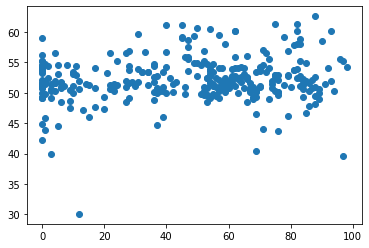

In [24]:
urgeResults = urgey_test_clean
urgeResults['urge_restrict_overall'] = urgeyPred

plt.scatter(urgeResults['urge_restrict'], urgeResults['urge_restrict_overall'])

In [25]:
for train_index, test_index in cv.split(restX_cross):
    restX_train, restX_test = restX_cross.iloc[train_index, :], restX_cross.iloc[test_index,:]
    resty_train, resty_test = resty_cross.iloc[train_index], resty_cross.iloc[test_index]
    
restX_train_clean = restX_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restX_test_clean = restX_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
resty_train_clean = resty_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
resty_test_clean = resty_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

restX_cv_train = restX_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
resty_cv_train = resty_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

In [26]:
restMod = ElasticNet(max_iter = 1000) 
restcv_result = cross_validation(restMod, restX_cv_train, resty_cv_train, cv) #this does the cross validation

Best parameters : {'alpha': 1, 'l1_ratio': 0.7, 'tol': 0.001}


In [27]:
restcv_result

{'results':     mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
 0        0.023204      0.008282         0.005801    7.486086e-04         0.1   
 1        0.021405      0.005785         0.006001    8.949489e-04         0.1   
 2        0.021005      0.006872         0.005601    4.898041e-04         0.1   
 3        0.021405      0.005278         0.005601    7.999421e-04         0.1   
 4        0.020005      0.005178         0.006602    1.200358e-03         0.1   
 5        0.018404      0.003383         0.006002    1.095453e-03         0.1   
 6        0.020805      0.005155         0.007601    1.625107e-03         0.1   
 7        0.018404      0.005390         0.005801    3.999950e-04         0.1   
 8        0.019604      0.005537         0.005802    7.483027e-04         0.1   
 9        0.019204      0.003545         0.005602    7.999420e-04         0.1   
 10       0.016404      0.002417         0.005601    4.903884e-04         0.1   
 11       0.02080

In [28]:
restModTuned = ElasticNet(alpha = float(restcv_result['alpha']), l1_ratio = float(restcv_result['l1']), tol = float(restcv_result['tol']), max_iter = 1000).fit(restX_train_clean,resty_train_clean)
restyPred = restModTuned.predict(restX_test_clean)
print('MAE = ' + str(mae(resty_test_clean,restyPred))) #out of sample (OOS) MAE = 33.08
print('R2 = ' + str(r2_score(resty_test_clean,restyPred))) #OOS R2 = -1.67
print('RMSE = ' + str(sqrt(mse(resty_test_clean,restyPred)))) # RMSE = 36.08

MAE = 29.27590515562132
R2 = 0.022079795311906403
RMSE = 32.828530869177484


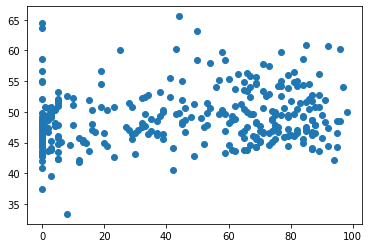

In [29]:
restResults = resty_test_clean
restResults['restrict_overall'] = restyPred

plt.scatter(restResults['restrict'], restResults['restrict_overall'])

In [30]:
###diagnostic-specific models now

pd.set_option("display.max.rows", None)
idiographicDx = raw[["PR","currentdx1_ade7bc"]]
idiographicDx.drop_duplicates(keep='first')

idiographicDx

,PR,currentdx1_ade7bc
0,PR003,1.0
1,PR003,1.0
2,PR003,1.0
3,PR003,1.0
4,PR003,1.0
5,PR003,1.0
6,PR003,1.0
7,PR003,1.0
8,PR003,1.0
9,PR003,1.0


In [31]:
#coding values: 1 = AN, 2 = BN, 3 = BED, 4 = OSFED... there should  be no BED cases. 
#we will look at AN and BN specifically for now

### starting with the urge data
### we need to filter both the complete dataset for cross-validation and then the time/test split that was already done 
### that's so we maintain the same timepoints in the same folds 



    
bnmask = raw['currentdx1_ade7bc'].values == 2
bn = raw.loc[bnmask]

anmask = raw['currentdx1_ade7bc'].values == 1
an = raw.loc[anmask]

osfedmask = raw['currentdx1_ade7bc'].values == 4
osfed = raw.loc[osfedmask]

restrictFilter = raw.groupby('PR').mean('restrict') # anyone with a mean restriction endorsement >= 40 for this analysis
restrictMask = restrictFilter['restrict'].values >= 40
restrictOnly = restrictFilter.loc[restrictMask]
restrictOnly = restrictOnly.rename_axis('PR').reset_index()
restIdList = restrictOnly['PR'].copy()

urgeMask = restrictFilter['urge_restrict'].values >= 40
urgeOnly = restrictFilter.loc[urgeMask]
urgeOnly = urgeOnly.rename_axis('PR').reset_index()
urgeIdList = urgeOnly['PR'].copy()

In [32]:
#full dataset for final model validation on BN only 
    
bn_urge_mask = urgeX_cross['currentdx1_ade7bc'].values == 2
bn_urgeX = urgeX_cross.loc[bn_urge_mask]
bn_urgeX = bn_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgey = urgey_cross.loc[bn_urge_mask]
bn_urgey = bn_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [33]:
#for train_index, test_index in cv.split(urgeX_cross):
    #urgeX_train, urgeX_test = urgeX_cross.iloc[train_index, :], urgeX_cross.iloc[test_index,:]
    #urgey_train, urgey_test = urgey_cross.iloc[train_index], urgey_cross.iloc[test_index]
    
#now we're filtering the BN cases in the train/test splits

bn_urgeX_train_mask = urgeX_train['currentdx1_ade7bc'].values == 2
bn_urgeX_train = urgeX_train.loc[bn_urgeX_train_mask]
bn_urgeX_train = bn_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgeX_test_mask = urgeX_test['currentdx1_ade7bc'].values == 2
bn_urgeX_test = urgeX_test.loc[bn_urgeX_test_mask]
bn_urgeX_test = bn_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgey_train_mask = urgey_train['currentdx1_ade7bc'].values == 2
bn_urgey_train = urgey_train.loc[bn_urgey_train_mask]
bn_urgey_train = bn_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgey_test_mask = urgey_test['currentdx1_ade7bc'].values == 2
bn_urgey_test = urgey_test.loc[bn_urgey_test_mask]
bn_urgey_test = bn_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [34]:
#ANALYSIS FOR BN
bnUrgeMod = ElasticNet(max_iter = 5000) 
bnUrgecv_result = cross_validation(bnUrgeMod, bn_urgeX, bn_urgey, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}


In [35]:
bnUrgeModTuned = ElasticNet(alpha = float(bnUrgecv_result['alpha']), l1_ratio = float(bnUrgecv_result['l1']), tol = float(bnUrgecv_result['tol']), max_iter = 1000).fit(bn_urgeX_train,bn_urgey_train)
bnUrgeyPred = bnUrgeModTuned.predict(bn_urgeX_test)
print('MAE = ' + str(mae(bn_urgey_test,bnUrgeyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(bn_urgey_test,bnUrgeyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(bn_urgey_test,bnUrgeyPred)))) # RMSE = 43.70

MAE = 22.15848054253909
R2 = -0.10813339774675779
RMSE = 25.49418032430128


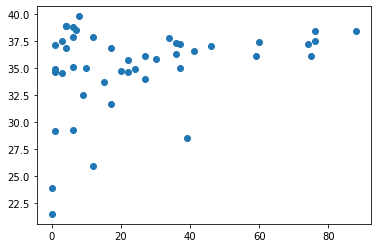

In [36]:
urge_bn_Results = bn_urgey_test
urge_bn_Results['urge_restrict_bn'] = bnUrgeyPred

plt.scatter(urge_bn_Results['urge_restrict'], urge_bn_Results['urge_restrict_bn'])

In [37]:
#full dataset for final model validation on BN only 
    
bn_rest_mask = restX_cross['currentdx1_ade7bc'].values == 2
bn_restX = restX_cross.loc[bn_rest_mask]
bn_restX = bn_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_resty = resty_cross.loc[bn_rest_mask]
bn_resty = bn_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the BN cases in the train/test splits

bn_restX_train_mask = restX_train['currentdx1_ade7bc'].values == 2
bn_restX_train = restX_train.loc[bn_restX_train_mask]
bn_restX_train = bn_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_restX_test_mask = restX_test['currentdx1_ade7bc'].values == 2
bn_restX_test = restX_test.loc[bn_restX_test_mask]
bn_restX_test = bn_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_resty_train_mask = resty_train['currentdx1_ade7bc'].values == 2
bn_resty_train = resty_train.loc[bn_resty_train_mask]
bn_resty_train = bn_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_resty_test_mask = resty_test['currentdx1_ade7bc'].values == 2
bn_resty_test = resty_test.loc[bn_resty_test_mask]
bn_resty_test = bn_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [38]:
#ANALYSIS FOR BN
bnRestMod = ElasticNet(max_iter = 5000) 
bnRestcv_result = cross_validation(bnRestMod, bn_restX, bn_resty, cv) #this does the cross validation

Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.0001}


In [39]:
bnRestcv_result

{'results':     mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
 0        0.018603  3.612042e-03         0.004601    4.899793e-04         0.1   
 1        0.016003  2.683887e-03         0.004601    4.899403e-04         0.1   
 2        0.017804  2.482393e-03         0.004601    4.899404e-04         0.1   
 3        0.016803  2.482758e-03         0.004601    4.901740e-04         0.1   
 4        0.019604  3.262779e-03         0.005001    6.326359e-04         0.1   
 5        0.016604  3.383263e-03         0.005401    4.900766e-04         0.1   
 6        0.020605  4.842834e-03         0.006201    1.470048e-03         0.1   
 7        0.017804  3.187975e-03         0.005001    6.326360e-04         0.1   
 8        0.019804  3.371330e-03         0.005001    6.324097e-04         0.1   
 9        0.018404  3.611667e-03         0.005401    1.200080e-03         0.1   
 10       0.023805  6.210802e-03         0.008602    6.712635e-03         0.1   
 11       0.01680

In [40]:
bnRestModTuned = ElasticNet(alpha = float(bnRestcv_result['alpha']), l1_ratio = float(bnRestcv_result['l1']), tol = float(bnRestcv_result['tol']), max_iter = 1000).fit(bn_restX_train,bn_resty_train)
bnRestyPred = bnRestModTuned.predict(bn_restX_test)
print('MAE = ' + str(mae(bn_resty_test,bnRestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(bn_resty_test,bnRestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(bn_resty_test,bnRestyPred)))) # RMSE = 43.70

MAE = 23.52916978790429
R2 = -0.5687290554877904
RMSE = 26.537829105980492


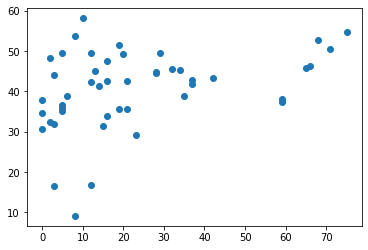

In [41]:
rest_bn_Results = bn_resty_test
rest_bn_Results['restrict_bn'] = bnRestyPred

plt.scatter(rest_bn_Results['restrict'], rest_bn_Results['restrict_bn'])

In [42]:
rest_bn_Results

,restrict,restrict_bn
1439,28.0,44.594731
1236,0.0,34.593077
1182,3.0,31.941101
1181,8.0,9.132153
1438,42.0,43.217218
1180,14.0,41.424415
1437,29.0,49.600949
1436,10.0,58.146365
1235,0.0,30.585780
1179,16.0,33.853405


In [43]:
rest_bn_Results = pd.merge(rest_bn_Results, restResults, left_index=True, right_index=True, how='inner')

In [44]:
rest_bn_Results

,restrict_x,restrict_bn,restrict_y,restrict_overall
1439,28.0,44.594731,28.0,46.989564
1236,0.0,34.593077,0.0,64.537095
1182,3.0,31.941101,3.0,43.785178
1181,8.0,9.132153,8.0,33.367689
1438,42.0,43.217218,42.0,44.061018
1180,14.0,41.424415,14.0,44.954401
1437,29.0,49.600949,29.0,50.736317
1436,10.0,58.146365,10.0,52.229264
1235,0.0,30.585780,0.0,63.689885
1179,16.0,33.853405,16.0,48.061995


In [45]:
#full dataset for final model validation on an only 
    
an_urge_mask = urgeX_cross['currentdx1_ade7bc'].values == 1
an_urgeX = urgeX_cross.loc[an_urge_mask]
an_urgeX = an_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgey = urgey_cross.loc[an_urge_mask]
an_urgey = an_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgeX_train_mask = urgeX_train['currentdx1_ade7bc'].values == 1
an_urgeX_train = urgeX_train.loc[an_urgeX_train_mask]
an_urgeX_train = an_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgeX_test_mask = urgeX_test['currentdx1_ade7bc'].values == 1
an_urgeX_test = urgeX_test.loc[an_urgeX_test_mask]
an_urgeX_test = an_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgey_train_mask = urgey_train['currentdx1_ade7bc'].values == 1
an_urgey_train = urgey_train.loc[an_urgey_train_mask]
an_urgey_train = an_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgey_test_mask = urgey_test['currentdx1_ade7bc'].values == 1
an_urgey_test = urgey_test.loc[an_urgey_test_mask]
an_urgey_test = an_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [46]:
#ANALYSIS FOR AN
anUrgeMod = ElasticNet(max_iter = 5000) 
anUrgecv_result = cross_validation(anUrgeMod, an_urgeX, an_urgey, cv) #this does the cross validation

Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.001}


In [47]:
anUrgeModTuned = ElasticNet(alpha = float(anUrgecv_result['alpha']), l1_ratio = float(anUrgecv_result['l1']), tol = float(anUrgecv_result['tol']), max_iter = 1000).fit(an_urgeX_train,an_urgey_train)
anUrgeyPred = anUrgeModTuned.predict(an_urgeX_test)
print('MAE = ' + str(mae(an_urgey_test,anUrgeyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(an_urgey_test,anUrgeyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(an_urgey_test,anUrgeyPred)))) # RMSE = 43.70

MAE = 23.764531944601544
R2 = 0.009878827368484777
RMSE = 29.12189017909444


In [48]:
#now we do AN

#full dataset for final model validation on an only 
    
an_rest_mask = restX_cross['currentdx1_ade7bc'].values == 1
an_restX = restX_cross.loc[an_rest_mask]
an_restX = an_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_resty = resty_cross.loc[an_rest_mask]
an_resty = an_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the an cases in the train/test splits

an_restX_train_mask = restX_train['currentdx1_ade7bc'].values == 1
an_restX_train = restX_train.loc[an_restX_train_mask]
an_restX_train = an_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_restX_test_mask = restX_test['currentdx1_ade7bc'].values == 1
an_restX_test = restX_test.loc[an_restX_test_mask]
an_restX_test = an_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_resty_train_mask = resty_train['currentdx1_ade7bc'].values == 1
an_resty_train = resty_train.loc[an_resty_train_mask]
an_resty_train = an_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_resty_test_mask = resty_test['currentdx1_ade7bc'].values == 1
an_resty_test = resty_test.loc[an_resty_test_mask]
an_resty_test = an_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [49]:
#ANALYSIS FOR AN
anRestMod = ElasticNet(max_iter = 5000) 
anRestcv_result = cross_validation(anRestMod, an_restX, an_resty, cv) #this does the cross validation

Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.001}


In [50]:
anRestModTuned = ElasticNet(alpha = float(anRestcv_result['alpha']), l1_ratio = float(anRestcv_result['l1']), tol = float(anRestcv_result['tol']), max_iter = 5000).fit(an_restX_train,an_resty_train)
anRestyPred = anRestModTuned.predict(an_restX_test)
print('MAE = ' + str(mae(an_resty_test,anRestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(an_resty_test,anRestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(an_resty_test,anRestyPred)))) # RMSE = 43.70

MAE = 30.37527096807288
R2 = 0.032933547053737855
RMSE = 34.30705161916079


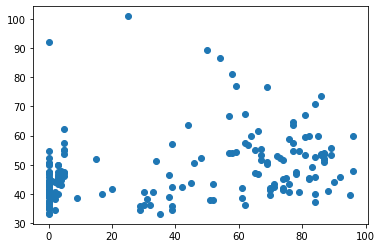

In [51]:
rest_an_Results = an_resty_test
rest_an_Results['restrict_an'] = anRestyPred
rest_an_Results = pd.merge(rest_an_Results, restResults, left_index=True, right_index=True, how='inner')

plt.scatter(rest_an_Results['restrict_x'], rest_an_Results['restrict_an'])

In [52]:
#full dataset for final model validation on OSFED only 
    
osfed_urge_mask = urgeX_cross['currentdx1_ade7bc'].values == 4
osfed_urgeX = urgeX_cross.loc[osfed_urge_mask]
osfed_urgeX = osfed_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgey = urgey_cross.loc[osfed_urge_mask]
osfed_urgey = osfed_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgeX_train_mask = urgeX_train['currentdx1_ade7bc'].values == 4
osfed_urgeX_train = urgeX_train.loc[osfed_urgeX_train_mask]
osfed_urgeX_train = osfed_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgeX_test_mask = urgeX_test['currentdx1_ade7bc'].values == 4
osfed_urgeX_test = urgeX_test.loc[osfed_urgeX_test_mask]
osfed_urgeX_test = osfed_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgey_train_mask = urgey_train['currentdx1_ade7bc'].values == 4
osfed_urgey_train = urgey_train.loc[osfed_urgey_train_mask]
osfed_urgey_train = osfed_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgey_test_mask = urgey_test['currentdx1_ade7bc'].values == 4
osfed_urgey_test = urgey_test.loc[osfed_urgey_test_mask]
osfed_urgey_test = osfed_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [53]:
#ANALYSIS FOR osfed
osfedUrgeMod = ElasticNet(max_iter = 5000) 
osfedUrgecv_result = cross_validation(osfedUrgeMod, osfed_urgeX, osfed_urgey, cv) #this does the cross validation

Best parameters : {'alpha': 0.01, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}


In [54]:
osfedUrgeModTuned = ElasticNet(alpha = float(osfedUrgecv_result['alpha']), l1_ratio = float(osfedUrgecv_result['l1']), tol = float(osfedUrgecv_result['tol']), max_iter = 5000).fit(osfed_urgeX_train,osfed_urgey_train)
osfedUrgeyPred = osfedUrgeModTuned.predict(osfed_urgeX_test)
print('MAE = ' + str(mae(osfed_urgey_test,osfedUrgeyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(osfed_urgey_test,osfedUrgeyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(osfed_urgey_test,osfedUrgeyPred)))) # RMSE = 43.70

MAE = 17.161381615974783
R2 = 0.11108535137258602
RMSE = 20.917109746789176


Text(0, 0.5, 'OSFED Model Predicted Values')

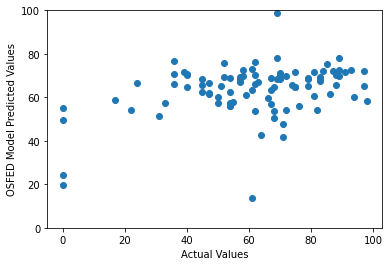

In [55]:
urge_osfed_Results = osfed_urgey_test
urge_osfed_Results['urge_restrict_osfed'] = osfedUrgeyPred
urge_osfed_Results = pd.merge(urge_osfed_Results, urgeResults, left_index=True, right_index=True, how='inner')


plt.scatter(urge_osfed_Results['urge_restrict_x'], urge_osfed_Results['urge_restrict_osfed'])
plt.ylim(0,100)
plt.xlabel("Actual Values")
plt.ylabel("OSFED Model Predicted Values")

Text(0, 0.5, 'Overall Model Predicted Values')

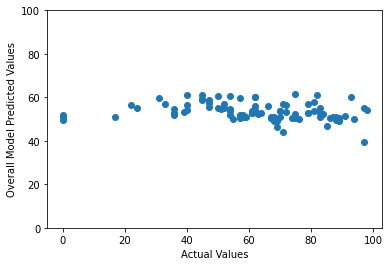

In [56]:
plt.scatter(urge_osfed_Results['urge_restrict_x'], urge_osfed_Results['urge_restrict_overall'])
plt.ylim(0,100)
plt.xlabel("Actual Values")
plt.ylabel("Overall Model Predicted Values")

In [57]:
osfed_rest_mask = restX_cross['currentdx1_ade7bc'].values == 4
osfed_restX = restX_cross.loc[osfed_rest_mask]
osfed_restX = osfed_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_resty = resty_cross.loc[osfed_rest_mask]
osfed_resty = osfed_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the osfed cases in the train/test splits

osfed_restX_train_mask = restX_train['currentdx1_ade7bc'].values == 4
osfed_restX_train = restX_train.loc[osfed_restX_train_mask]
osfed_restX_train = osfed_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_restX_test_mask = restX_test['currentdx1_ade7bc'].values == 4
osfed_restX_test = restX_test.loc[osfed_restX_test_mask]
osfed_restX_test = osfed_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_resty_train_mask = resty_train['currentdx1_ade7bc'].values == 4
osfed_resty_train = resty_train.loc[osfed_resty_train_mask]
osfed_resty_train = osfed_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_resty_test_mask = resty_test['currentdx1_ade7bc'].values == 4
osfed_resty_test = resty_test.loc[osfed_resty_test_mask]
osfed_resty_test = osfed_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [58]:
osfedRestMod = ElasticNet(max_iter = 5000) 
osfedRestcv_result = cross_validation(osfedRestMod, osfed_restX, osfed_resty, cv) #this does the cross validation

Best parameters : {'alpha': 0.1, 'l1_ratio': 0.7999999999999999, 'tol': 0.001}


In [59]:
osfedRestModTuned = ElasticNet(alpha = float(osfedRestcv_result['alpha']), l1_ratio = float(osfedRestcv_result['l1']), tol = float(osfedRestcv_result['tol']), max_iter = 5000).fit(osfed_restX_train,osfed_resty_train)
osfedRestyPred = osfedRestModTuned.predict(osfed_restX_test)
print('MAE = ' + str(mae(osfed_resty_test,osfedRestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(osfed_resty_test,osfedRestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(osfed_resty_test,osfedRestyPred)))) # RMSE = 43.70

MAE = 20.60003663814747
R2 = 0.00822050616596015
RMSE = 23.754666478849828


Text(0, 0.5, 'OSFED Model Predicted Values')

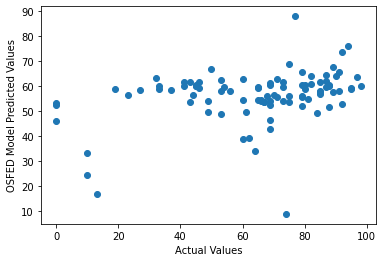

In [60]:
rest_osfed_Results = osfed_resty_test
rest_osfed_Results['restrict_osfed'] = osfedRestyPred
rest_osfed_Results = pd.merge(rest_osfed_Results, restResults, left_index=True, right_index=True, how='inner')


plt.scatter(rest_osfed_Results['restrict_x'], rest_osfed_Results['restrict_osfed'])
plt.xlabel("Actual Values")
plt.ylabel("OSFED Model Predicted Values")

Text(0, 0.5, 'Overall Model Predicted Values')

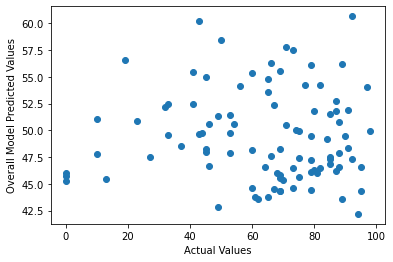

In [61]:
plt.scatter(rest_osfed_Results['restrict_x'], rest_osfed_Results['restrict_overall'])
plt.xlabel("Actual Values")
plt.ylabel("Overall Model Predicted Values")

In [62]:
urgeData

,PR,currentdx1_ade7bc,beepconsec,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAV,meanCenteredEDA_Median,...,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,meanCenteredTEMP_Slope,urge_restrict
1955,PR128,4.0,1,-0.025919,-0.087461,0.011207,2.013943e-02,0.032821,0.087461,-0.019546,...,-0.525116,0.894884,0.394429,0.404509,0.894884,-0.045116,-0.205116,0.484884,-1.747041e-12,63.0
117,PR003,1.0,1,0.065352,0.002917,0.120778,1.077259e-02,0.066233,0.120778,0.065691,...,-2.820798,-1.560798,0.262720,2.284785,2.820798,-2.320798,-2.420798,-2.140798,6.031525e-13,91.0
1039,PR038,1.0,1,-1.037859,-1.202684,-0.118739,1.117575e-01,1.043857,1.202684,-1.046380,...,-7.945477,-7.145477,0.177652,7.706557,7.945477,-7.765477,-7.825477,-7.665477,9.029768e-13,33.0
1265,PR073,2.0,1,-0.840773,-0.907049,-0.817388,1.632438e-02,0.840932,0.907049,-0.837882,...,-3.841141,-1.701141,0.596943,3.071568,3.841141,-3.121141,-3.601141,-2.581141,3.311553e-12,60.0
944,PR037,4.0,1,-0.024593,-0.049741,0.011759,9.590271e-03,0.026396,0.049741,-0.026678,...,-1.601043,-1.281043,0.080851,1.467744,1.601043,-1.481043,-1.541043,-1.401043,-1.076508e-13,61.0
1635,PR102,4.0,1,-0.036773,-0.094810,-0.007695,1.008921e-02,0.038132,0.094810,-0.037160,...,-0.637806,0.042194,0.158038,0.310050,0.637806,-0.257806,-0.387806,-0.137806,-2.971512e-13,95.0
833,PR039,4.0,1,-0.237310,-0.289999,0.104699,2.786037e-02,0.238940,0.289999,-0.241302,...,-0.286564,0.213436,0.103069,0.103059,0.286564,-0.016564,-0.076564,0.043436,4.687841e-13,0.0
1324,PR079,1.0,1,0.017543,-0.280190,0.157946,2.597388e-02,0.031339,0.280190,0.022149,...,-2.018903,-1.318903,0.166930,1.717776,2.018903,-1.738903,-1.818903,-1.598903,2.559842e-13,56.0
738,PR033,4.0,1,1.910256,1.000787,3.433496,4.449277e-01,1.961366,3.433496,1.957471,...,0.007112,0.247112,0.060251,0.172375,0.247112,0.187112,0.107112,0.207112,2.503987e-14,79.0
1404,PR084,2.0,1,16.313043,12.137970,23.561604,2.253494e+00,16.467893,23.561604,15.646235,...,1.239283,1.699283,0.098956,1.454331,1.699283,1.459283,1.379283,1.509283,-3.333300e-13,92.0


In [86]:
#testing if this works with the idiographic models

PRList = list(urgeData['PR'].unique())
resultsUrgeList = []
resultsRestrictList = []
restDict = []

for PR in PRList:
    curRestrictData = restrictData[restrictData['PR'] == PR]
    curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
    if (len(curRestrictData) <15) : # Don't use participants with fewer than 10 observations
        print('Skipping ' + PR + ' due to lack of data')
    else:   
        idio_rest_mask = restX_cross['PR'].isin([PR])
        idio_restX = restX_cross.loc[idio_rest_mask]
        idio_restX = idio_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_resty = resty_cross.loc[idio_rest_mask]
        idio_resty = idio_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        #now we're filtering the an cases in the train/test splits
        
        idio_restX_train_mask = restX_train['PR'].isin([PR])
        idio_restX_train = restX_train.loc[idio_restX_train_mask]
        idio_restX_train = idio_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        idio_restX_test_mask = restX_test['PR'].isin([PR])
        idio_restX_test = restX_test.loc[idio_restX_test_mask]
        idio_restX_test = idio_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_resty_train_mask = resty_train['PR'].isin([PR])
        idio_resty_train = resty_train.loc[idio_resty_train_mask]
        idio_resty_train = idio_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_resty_test_mask = resty_test['PR'].isin([PR])
        idio_resty_test = resty_test.loc[idio_resty_test_mask]
        idio_resty_test = idio_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        if (len(idio_resty_test) == 0 ) :
            print('Skipping ' + PR + ' due to lack of holdout set')
        else:
            idioRestMod = ElasticNet(max_iter = 5000)
            idioRestcv_result = cross_validation(idioRestMod, idio_restX, idio_resty, cv) #this does the cross validation
            idioRestModTuned = ElasticNet(alpha = float(idioRestcv_result['alpha']), l1_ratio = float(idioRestcv_result['l1']), tol = float(idioRestcv_result['tol']), max_iter = 5000).fit(idio_restX_train,idio_resty_train)
            idioRestyPred = idioRestModTuned.predict(idio_restX_test)
            
            print(PR)
            print('MAE = ' + str(mae(idio_resty_test,idioRestyPred))) 
            print('R2 = ' + str(r2_score(idio_resty_test,idioRestyPred))) 
            print('RMSE = ' + str(sqrt(mse(idio_resty_test,idioRestyPred))))
            
            results = idio_resty_test
            results['restrict_prediction'] = idioRestyPred
            results['participant_id'] = PR
            restDict.append(results)

<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}
PR128
MAE = 17.776817866459133
R2 = -2.11232059517661
RMSE = 19.944565557302134


<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}
PR003
MAE = 4.12440979449402
R2 = -0.16024115181933962
RMSE = 5.369007297517926


<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


...

<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
PR116
MAE = 8.425878892625647
R2 = -0.030090021389098887
RMSE = 10.996350154770187
Skipping PR022 due to lack of data


<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.7, 'tol': 0.0001}
PR048
MAE = 19.44781074960116
R2 = -13.41077179283905
RMSE = 24.19742162123582
Skipping PR117 due to lack of data


<ipython-input-86-6c546c969f57>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


In [87]:
restDict

[      restrict  restrict_prediction participant_id
 1901      49.0            58.532677          PR128
 1900      50.0            58.452501          PR128
 1899      32.0            58.991755          PR128
 1898      23.0            58.820340          PR128
 1897      33.0            60.026961          PR128
 1895      41.0            58.759450          PR128
 1896      41.0            59.696778          PR128
 1894      66.0            58.304397          PR128
 1893      49.0            59.012863          PR128
 1892      43.0            58.779251          PR128,
     restrict  restrict_prediction participant_id
 21      96.0            84.257978          PR003
 19      87.0            83.615645          PR003
 17      87.0            83.862805          PR003
 18      87.0            83.862805          PR003
 20      87.0            83.615645          PR003
 16      88.0            84.447440          PR003
 15      87.0            83.700897          PR003
 14      90.0            84

In [82]:
#testing if this works with the idiographic models


PRList = list(urgeData['PR'].unique())
resultsUrgeList = []
urgeDict = []

for PR in PRList:
    curUrgeData = urgeData[urgeData['PR'] == PR]
    curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
    if (len(curUrgeData) < 15 ) : # Don't use participants with fewer than 10 observations
        print('Skipping ' + PR + ' due to lack of data')
    else:   
        idio_urge_mask = urgeX_cross['PR'].isin([PR])
        idio_urgeX = urgeX_cross.loc[idio_urge_mask]
        idio_urgeX = idio_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_urgey = urgey_cross.loc[idio_urge_mask]
        idio_urgey = idio_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        #now we're filtering the an cases in the train/test splits
        
        idio_urgeX_train_mask = urgeX_train['PR'].isin([PR])
        idio_urgeX_train = urgeX_train.loc[idio_urgeX_train_mask]
        idio_urgeX_train = idio_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        idio_urgeX_test_mask = urgeX_test['PR'].isin([PR])
        idio_urgeX_test = urgeX_test.loc[idio_urgeX_test_mask]
        idio_urgeX_test = idio_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_urgey_train_mask = urgey_train['PR'].isin([PR])
        idio_urgey_train = urgey_train.loc[idio_urgey_train_mask]
        idio_urgey_train = idio_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_urgey_test_mask = urgey_test['PR'].isin([PR])
        idio_urgey_test = urgey_test.loc[idio_urgey_test_mask]
        idio_urgey_test = idio_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        if (len(idio_urgey_test) == 0 ) :
            print('Skipping ' + PR + ' due to lack of holdout set')
        else:
            idiourgeMod = ElasticNet(max_iter = 5000)
            idiourgecv_result = cross_validation(idiourgeMod, idio_urgeX, idio_urgey, cv) #this does the cross validation
            idiourgeModTuned = ElasticNet(alpha = float(idiourgecv_result['alpha']), l1_ratio = float(idiourgecv_result['l1']), tol = float(idiourgecv_result['tol']), max_iter = 5000).fit(idio_urgeX_train,idio_urgey_train)
            idiourgeyPred = idiourgeModTuned.predict(idio_urgeX_test)
            
            print(PR)
            print('MAE = ' + str(mae(idio_urgey_test,idiourgeyPred))) 
            print('R2 = ' + str(r2_score(idio_urgey_test,idiourgeyPred)))
            print('RMSE = ' + str(sqrt(mse(idio_urgey_test,idiourgeyPred)))) 
            
            results = idio_urgey_test
            results['urge_restrict_prediction'] = idiourgeyPred
            results['participant_id'] = PR
            urgeDict.append(results)


<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}
PR128
MAE = 19.01721741812404
R2 = -0.7855427819241265
RMSE = 20.78747720752708


<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
PR003
MAE = 4.2291840244749785
R2 = -0.02862367109140762
RMSE = 5.38330607100667


<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing


...

<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}
PR116
MAE = 13.464646277735643
R2 = -0.595951319065088
RMSE = 17.095296353822565
Skipping PR022 due to lack of data


<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
PR048
MAE = 14.794082188169899
R2 = -1.0061719944783092
RMSE = 16.33701963927245
Skipping PR117 due to lack of data


<ipython-input-82-222543bd0dd7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing


In [84]:
urgeDict

[      urge_restrict  urge_restrict_prediction participant_id
 1901           50.0                 59.580105          PR128
 1900           45.0                 58.976625          PR128
 1899           22.0                 58.093038          PR128
 1898           36.0                 56.536892          PR128
 1897           33.0                 57.682355          PR128
 1896           45.0                 57.722431          PR128
 1895           45.0                 57.156327          PR128
 1894           31.0                 58.474269          PR128
 1893           54.0                 63.654140          PR128
 1892           82.0                 58.704007          PR128,
     urge_restrict  urge_restrict_prediction participant_id
 21           76.0                 82.440245          PR003
 19           83.0                 81.418624          PR003
 17           83.0                 81.452672          PR003
 20           82.0                 81.418624          PR003
 18           82.

In [65]:
curUrgeData

,PR,currentdx1_ade7bc,beepconsec,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAV,meanCenteredEDA_Median,...,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,meanCenteredTEMP_Slope,urge_restrict
1818,PR117,1.0,33,0.850244,0.396167,1.463505,1.084751e-01,0.857133,1.463505,0.834197,...,-3.031891,-2.591891,0.089443,2.808908,3.031891,-2.791891,-2.851891,-2.751891,-7.346051e-14,56.0
1817,PR117,1.0,34,-0.119625,-0.142168,0.797933,2.537734e-02,0.122286,0.797933,-0.121675,...,-0.271891,0.688109,0.258463,0.333743,0.688109,0.208109,-0.011891,0.388109,1.414831e-12,30.0
1816,PR117,1.0,41,4.202050,3.806204,5.444402,2.211406e-01,4.207862,5.444402,4.188683,...,-5.931891,-5.171891,0.177093,5.489357,5.931891,-5.451891,-5.611891,-5.351891,-3.853820e-13,60.0
1815,PR117,1.0,42,2.025298,0.729333,3.003377,1.223613e-01,2.028989,3.003377,2.022696,...,-4.171891,-2.911891,0.298402,3.659466,4.171891,-3.611891,-3.931891,-3.411891,1.442038e-12,16.0
1814,PR117,1.0,43,-1.590096,-1.590096,-1.590096,3.664499e-14,1.590096,1.590096,-1.590096,...,-11.211891,-8.611891,0.640533,10.556473,11.211891,-10.751891,-11.051891,-10.211891,-3.384856e-12,62.0
1813,PR117,1.0,44,-1.555366,-1.590096,-1.541432,1.119789e-02,1.555406,1.590096,-1.552317,...,-1.051891,-0.871891,0.056056,0.953210,1.051891,-0.951891,-1.006891,-0.911891,-3.148406e-12,16.0
1812,PR117,1.0,47,-1.590033,-1.590096,-1.586254,4.222399e-04,1.590033,1.590096,-1.590096,...,-0.611891,-0.511891,0.020999,0.555998,0.611891,-0.551891,-0.571891,-0.531891,-4.294228e-13,44.0
1811,PR117,1.0,53,-1.004722,-1.217141,-0.777856,2.953252e-02,1.005156,1.217141,-0.996859,...,-4.791891,-4.091891,0.159657,4.443522,4.791891,-4.451891,-4.571891,-4.311891,1.889958e-13,34.0
1810,PR117,1.0,54,-1.349716,-1.456635,-0.812702,4.571287e-02,1.350490,1.456635,-1.363143,...,-1.611891,-0.971891,0.157394,1.300323,1.611891,-1.271891,-1.411891,-1.171891,-4.957963e-13,15.0
1809,PR117,1.0,55,-1.590096,-1.590096,-1.590096,3.664499e-14,1.590096,1.590096,-1.590096,...,-0.131891,0.588109,0.197194,0.328928,0.588109,0.268109,0.128109,0.448109,-1.104507e-12,29.0


In [66]:
restX_cross['PR'].unique()

['PR128', 'PR038', 'PR073', 'PR037', 'PR011', ..., 'PR126', 'PR116', 'PR022', 'PR048', 'PR117']
Length: 37
Categories (37, object): ['PR003', 'PR008', 'PR010', 'PR011', ..., 'PR116', 'PR117', 'PR126', 'PR128']

In [67]:
restX_cross

,PR,currentdx1_ade7bc,beepconsec,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAV,meanCenteredEDA_Median,...,meanCenteredTEMP_Mean,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,meanCenteredTEMP_Slope
1955,PR128,4.0,1,-0.025919,-0.087461,0.011207,2.013943e-02,0.032821,0.087461,-0.019546,...,0.090098,-0.525116,0.894884,0.394429,0.404509,0.894884,-0.045116,-0.205116,0.484884,-1.747041e-12
1039,PR038,1.0,1,-1.037859,-1.202684,-0.118739,1.117575e-01,1.043857,1.202684,-1.046380,...,-7.704510,-7.945477,-7.145477,0.177652,7.706557,7.945477,-7.765477,-7.825477,-7.665477,9.029768e-13
1265,PR073,2.0,1,-0.840773,-0.907049,-0.817388,1.632438e-02,0.840932,0.907049,-0.837882,...,-3.013028,-3.841141,-1.701141,0.596943,3.071568,3.841141,-3.121141,-3.601141,-2.581141,3.311553e-12
944,PR037,4.0,1,-0.024593,-0.049741,0.011759,9.590271e-03,0.026396,0.049741,-0.026678,...,-1.465517,-1.601043,-1.281043,0.080851,1.467744,1.601043,-1.481043,-1.541043,-1.401043,-1.076508e-13
375,PR011,1.0,1,10.716578,3.084089,21.966890,5.552098e+00,12.068886,21.966890,11.648262,...,-7.740030,-8.054724,-7.254724,0.221478,7.743197,8.054724,-7.774724,-7.934724,-7.594724,-1.105667e-12
1324,PR079,1.0,1,0.017543,-0.280190,0.157946,2.597388e-02,0.031339,0.280190,0.022149,...,-1.709649,-2.018903,-1.318903,0.166930,1.717776,2.018903,-1.738903,-1.818903,-1.598903,2.559842e-13
833,PR039,4.0,1,-0.237310,-0.289999,0.104699,2.786037e-02,0.238940,0.289999,-0.241302,...,-0.001528,-0.286564,0.213436,0.103069,0.103059,0.286564,-0.016564,-0.076564,0.043436,4.687841e-13
391,PR018,1.0,1,-0.112823,-0.216482,0.180755,1.995039e-02,0.114572,0.216482,-0.112688,...,-0.138715,-0.341647,0.118353,0.124863,0.186618,0.341647,-0.141647,-0.241647,-0.041647,7.146807e-13
1635,PR102,4.0,1,-0.036773,-0.094810,-0.007695,1.008921e-02,0.038132,0.094810,-0.037160,...,-0.266768,-0.637806,0.042194,0.158038,0.310050,0.637806,-0.257806,-0.387806,-0.137806,-2.971512e-13
1141,PR042,1.0,1,-0.097639,-0.097639,-0.097639,2.998227e-15,0.097639,0.097639,-0.097639,...,-0.410704,-0.735269,-0.175269,0.143498,0.435041,0.735269,-0.415269,-0.515269,-0.295269,3.949998e-13


In [89]:
pr003_rest_mask = restX_cross['PR'].isin(['PR003'])
pr003_restX = restX_cross.loc[pr003_rest_mask]
pr003_restX = pr003_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_resty = resty_cross.loc[pr003_rest_mask]
pr003_resty = pr003_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the an cases in the train/test splits

pr003_restX_train_mask = restX_train['PR'].isin(['PR003'])
pr003_restX_train = restX_train.loc[pr003_restX_train_mask]
pr003_restX_train = pr003_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_restX_test_mask = restX_test['PR'].isin(['PR003'])
pr003_restX_test = restX_test.loc[pr003_restX_test_mask]
pr003_restX_test = pr003_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_resty_train_mask = resty_train['PR'].isin(['PR003'])
pr003_resty_train = resty_train.loc[pr003_resty_train_mask]
pr003_resty_train = pr003_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_resty_test_mask = resty_test['PR'].isin(['PR003'])
pr003_resty_test = resty_test.loc[pr003_resty_test_mask]
pr003_resty_test = pr003_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [90]:
pr003RestMod = ElasticNet(max_iter = 5000) 
pr003Restcv_result = cross_validation(pr003RestMod, pr003_restX, pr003_resty, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}


In [91]:
pr003RestModTuned = ElasticNet(alpha = float(pr003Restcv_result['alpha']), l1_ratio = float(pr003Restcv_result['l1']), tol = float(pr003Restcv_result['tol']), max_iter = 5000).fit(pr003_restX_train,pr003_resty_train)
pr003RestyPred = pr003RestModTuned.predict(pr003_restX_test)
print('MAE = ' + str(mae(pr003_resty_test,pr003RestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(pr003_resty_test,pr003RestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(pr003_resty_test,pr003RestyPred)))) # RMSE = 43.70

MAE = 4.12440979449402
R2 = -0.16024115181933962
RMSE = 5.369007297517926


In [92]:
pr003RestyPred

array([84.25797837, 83.615645  , 83.86280499, 83.86280499, 83.615645  ,
       84.44744023, 83.70089695, 84.43578285, 84.36124627, 84.2876517 ,
       83.86551327, 84.00269354, 83.84431804, 84.16730987, 84.47864432,
       84.03896095, 84.07593486, 84.54550461, 84.51632474, 84.33946228,
       84.1200916 , 84.1655436 ])

In [93]:
pr003_resty_test

,restrict
21,96.0
19,87.0
17,87.0
18,87.0
20,87.0
16,88.0
15,87.0
14,90.0
13,81.0
12,89.0


In [94]:

rest_an_Results['restrict_bn'] = anRestyPred

plt.scatter(rest_an_Results['restrict'], rest_an_Results['restrict_bn'])

KeyError: 'restrict'

In [ ]:
rest_pr003_Results = pr003_resty_test
rest_pr003_Results['restrict_pr003'] = pr003RestyPred
rest_pr003_Results = pd.merge(rest_pr003_Results, rest_an_Results, left_index=True, right_index=True, how='inner')
rest_pr003_Results

plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_pr003'])

In [ ]:
plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_pr003'])
plt.title('PR003')
plt.xlabel("Actual Values")
plt.ylabel("PR003 Model Predicted Values")

In [ ]:
plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_an'])
plt.title('PR003')
plt.xlabel("Actual Values")
plt.ylabel("AN Model Predicted Values")

In [ ]:
plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_overall'])
plt.title('PR003')
plt.xlabel("Actual Values")
plt.ylabel("Overall Model Predicted Values")